# Advanced Sentence Embeddings

## Beyond Word Embeddings: The Need for Sentence-Level Representations

Word embeddings (Word2Vec, GloVe, FastText) gave us distributed representations of words. But language understanding requires capturing **meaning at the sentence level**.

### Problems with Word Embedding Aggregation

Naive approaches (mean/max pooling of word vectors) fail because:

1. **Compositionality**: "not happy" ≠ avg("not", "happy")
2. **Word order ignorance**: "Dog bites man" ≈ "Man bites dog" (same words!)
3. **Polysemy collapse**: "bank" (river) + "bank" (financial) → wrong average
4. **Context blindness**: "I went to the bank" which bank?

### The Goal

A good sentence embedding $\phi(s) \in \mathbb{R}^d$ should satisfy:

$$\text{sim}(\phi(s_1), \phi(s_2)) \approx \text{semantic\_similarity}(s_1, s_2)$$

### Applications
- Semantic search: find documents similar to a query
- Duplicate detection: identify paraphrases
- Clustering: group documents by topic
- Retrieval-Augmented Generation (RAG)
- Classification (embed then classify)

In [1]:
# Setup
# pip install sentence-transformers transformers torch faiss-cpu scikit-learn

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Tuple
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

def normalize(v: np.ndarray) -> np.ndarray:
    return v / (np.linalg.norm(v) + 1e-10)

print("Setup complete!")

Setup complete!


## 1. Sentence-BERT (SBERT)

**Paper**: "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks" (Reimers & Gurevych, 2019)

### The Problem with Vanilla BERT

BERT can compute sentence similarity but requires cross-encoding:
- Input: `[CLS] sentence_A [SEP] sentence_B [SEP]`
- For $n=10,000$ sentences: $\binom{10000}{2} = 49.9M$ inference calls!
- At 65ms each: **~65 days** to find the most similar pair.

SBERT creates independent sentence embeddings → comparison = dot product, $O(n)$ encoding + $O(n^2)$ comparisons (much faster).

### Siamese Network Architecture

```
Sentence A → BERT → Pooling → u ∈ ℝ^d
Sentence B → BERT → Pooling → v ∈ ℝ^d  (shared weights)
```

### Pooling Strategies

1. **CLS pooling**: use $h_{\text{[CLS]}}$
2. **Mean pooling**: $u = \frac{1}{T}\sum_{t=1}^T h_t$ (best for SBERT)
3. **Max pooling**: $u_i = \max_t h_{t,i}$

### Training Objectives

**Classification** (NLI): concatenate $[u; v; |u-v|]$, softmax → entailment/contradiction/neutral

**Regression** (STS): cosine similarity loss:
$$\mathcal{L} = \|\text{cos}(u, v) - y\|^2$$

**Triplet loss** (hardest negatives):
$$\mathcal{L} = \max(0, \|u - v^+\| - \|u - v^-\| + \epsilon)$$

**Contrastive loss** (in-batch negatives):
$$\mathcal{L} = \max(0, \epsilon - \cos(u, v) + \cos(u, v^-))$$

where $v^+$ is a positive pair, $v^-$ is a negative pair, $\epsilon$ is the margin.

In [2]:
# SBERT from scratch: Siamese BERT with mean pooling
import torch
import torch.nn as nn
import torch.nn.functional as F

class SiameseBERT(nn.Module):
    def __init__(self, model_name='bert-base-uncased'):
        super().__init__()
        from transformers import AutoModel
        self.encoder = AutoModel.from_pretrained(model_name)
        self.d_model = self.encoder.config.hidden_size
        
    def mean_pool(self, token_embeddings, attention_mask):
        """Mean pooling over non-padding tokens."""
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask
    
    def encode(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = self.mean_pool(outputs.last_hidden_state, attention_mask)
        return F.normalize(embeddings, p=2, dim=-1)  # L2 normalize
    
    def forward(self, batch_a, batch_b):
        u = self.encode(**batch_a)
        v = self.encode(**batch_b)
        return u, v


# Triplet loss
class TripletLoss(nn.Module):
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin
        
    def forward(self, anchor, positive, negative):
        dist_pos = 1 - F.cosine_similarity(anchor, positive)
        dist_neg = 1 - F.cosine_similarity(anchor, negative)
        loss = F.relu(dist_pos - dist_neg + self.margin)
        return loss.mean()


# In-batch contrastive loss (SimCSE style)
class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.05):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, embeddings_a, embeddings_b):
        # embeddings_a: (B, d), embeddings_b: (B, d)
        # Positive pairs: (i, i), negative pairs: all (i, j) where i != j
        sim = F.cosine_similarity(embeddings_a.unsqueeze(1), 
                                   embeddings_b.unsqueeze(0), dim=-1)  # (B, B)
        sim = sim / self.temperature
        labels = torch.arange(sim.size(0), device=sim.device)
        loss = F.cross_entropy(sim, labels)
        return loss

print("SBERT components defined!")

# Demo triplet loss
B, d = 4, 768
anchor = F.normalize(torch.randn(B, d), dim=-1)
positive = F.normalize(anchor + 0.1 * torch.randn(B, d), dim=-1)   # similar to anchor
negative = F.normalize(torch.randn(B, d), dim=-1)                   # random

triplet = TripletLoss(margin=0.5)
contrastive = ContrastiveLoss(temperature=0.05)

print(f"Triplet loss:     {triplet(anchor, positive, negative).item():.4f}")
print(f"Contrastive loss: {contrastive(anchor, positive).item():.4f}")

SBERT components defined!
Triplet loss:     0.1920
Contrastive loss: 0.0074


## 2. Early Sentence Embedding Models

### InferSent (2017)
Facebook AI. Trains on SNLI using BiLSTM with max pooling. First strong universal sentence encoder. Uses GloVe/fastText + BiLSTM → 4096-dim embeddings. **Key**: max-pooling over BiLSTM hidden states captures the most important features.

### Universal Sentence Encoder (USE, 2018)
Google. Two variants:
- **Transformer encoder**: better quality, higher compute
- **DAN** (Deep Averaging Network): average word vectors → deep feedforward, fast

Trained on SNLI + web data (question-answer pairs). Multitask: STS, classification, NLI.

### LASER (2019)
Meta AI. **Language-Agnostic SEntence Representations** 93 languages in one embedding space.

Architecture: BiLSTM encoder + LSTM decoder (seq2seq). Train to translate between language pairs. The bottleneck encoder learns language-agnostic representations.

$$\phi(s_{\text{EN}}) \approx \phi(s_{\text{FR}}) \approx \phi(s_{\text{ZH}}) \text{ (same semantic content)}$$

### LaBSE (Language-Agnostic BERT Sentence Embedding, 2020)
Google. BERT-based multilingual model (109 languages). Training:
1. Start from mBERT + translation language modeling
2. Fine-tune with **additive margin softmax** (AMS) loss on parallel corpora

$$\mathcal{L}_{\text{AMS}} = -\sum_i \log \frac{e^{\phi(x_i)^T \phi(y_i) - m}}{e^{\phi(x_i)^T \phi(y_i) - m} + \sum_{j\neq i} e^{\phi(x_i)^T \phi(y_j)}}$$

Loading SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding shape: (5, 384)


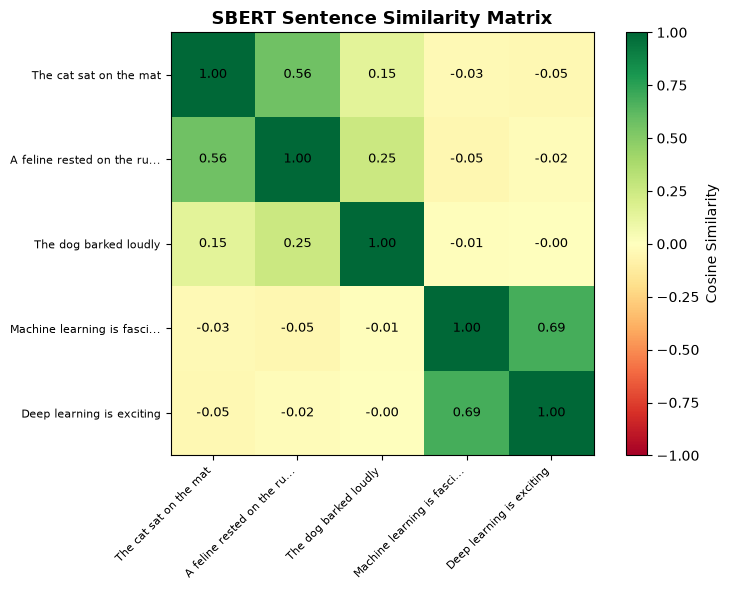


Cat sentence vs feline sentence: 0.564
Cat sentence vs dog sentence:    0.147
ML sentence vs DL sentence:      0.687


In [3]:
# Using sentence-transformers for SBERT and variants
from sentence_transformers import SentenceTransformer, util

# SBERT variants
print("Loading SBERT model...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')  # Fast SBERT variant

sentences = [
    "The cat sat on the mat",
    "A feline rested on the rug",    # Similar
    "The dog barked loudly",          # Different
    "Machine learning is fascinating",
    "Deep learning is exciting",      # Similar to above
]

embeddings = sbert.encode(sentences, normalize_embeddings=True)
print(f"Embedding shape: {embeddings.shape}")  # (5, 384)

# Compute pairwise similarities
sim_matrix = util.cos_sim(embeddings, embeddings).numpy()

# Visualize
plt.figure(figsize=(8, 6))
labels = [s[:25] + '...' if len(s) > 25 else s for s in sentences]
im = plt.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.xticks(range(len(sentences)), labels, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(sentences)), labels, fontsize=8)
plt.colorbar(im, label='Cosine Similarity')
plt.title('SBERT Sentence Similarity Matrix', fontsize=13, fontweight='bold')
for i in range(len(sentences)):
    for j in range(len(sentences)):
        plt.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nCat sentence vs feline sentence: {sim_matrix[0,1]:.3f}")
print(f"Cat sentence vs dog sentence:    {sim_matrix[0,2]:.3f}")
print(f"ML sentence vs DL sentence:      {sim_matrix[3,4]:.3f}")

## 3. Modern Text Embedding Models

### E5 Family (Microsoft, 2022-2024)
**"Text Embeddings by Weakly-Supervised Contrastive Pre-training"**

Key design: **text pair format** always prepend task instruction:
- Queries: `"query: <text>"`
- Documents: `"passage: <text>"`

Variants:
- `e5-small/base/large`: standard BERT-based
- `e5-mistral-7b-instruct`: instruction-tuned LLM backbone
- `multilingual-e5-large`: 100 languages

Training: weakly supervised on CC-Pairs (Common Crawl title+body pairs), then fine-tuned on labeled data.

### BGE (BAAI General Embedding, 2023-2024)
Beijing Academy of AI.

- `bge-base/large-en-v1.5`: standard BERT-based
- `bge-m3`: **M3-Embedding** Multi-Functionality, Multi-Linguality, Multi-Granularity

**M3-Embedding** is special: single model supports three retrieval modes:
1. **Dense retrieval**: $\text{score}(q, d) = \phi(q)^T \phi(d)$
2. **Sparse retrieval**: learned BM25-like term weights $w_t = \text{ReLU}(h_t \cdot W)$
3. **Multi-vector (ColBERT-style)**: $\text{score}(q, d) = \sum_i \max_j \phi_q(i)^T \phi_d(j)$

### GTE (General Text Embeddings, Alibaba 2023-2024)
- `gte-base/large/Qwen2-7B-instruct`
- Multi-stage training: unsupervised → supervised → fine-tuned
- `gte-Qwen2-7B` uses 7B LLM backbone, state-of-the-art on MTEB

### Jina Embeddings (2023-2024)
- `jina-embeddings-v3`: 8192 token context window
- **Late chunking**: embed the full document, then chunk embeddings (preserves cross-chunk context)
- ColBERT-style multi-vector support
- Task-specific LoRA adapters: retrieval, clustering, classification

In [4]:
# Comparing embedding models with sentence-transformers
from sentence_transformers import SentenceTransformer

# Model comparison (choose based on task and resources)
MODEL_CATALOG = {
    # SBERT variants
    "all-MiniLM-L6-v2":         {"dims": 384,  "params": "22M",   "context": 256,  "best_for": "Fast semantic search"},
    "all-mpnet-base-v2":        {"dims": 768,  "params": "109M",  "context": 384,  "best_for": "High-quality STS"},
    # E5
    "intfloat/e5-large-v2":     {"dims": 1024, "params": "335M",  "context": 512,  "best_for": "Retrieval (add 'query:' prefix)"},
    "intfloat/multilingual-e5-large": {"dims": 1024, "params": "560M", "context": 512, "best_for": "Multilingual retrieval"},
    # BGE
    "BAAI/bge-large-en-v1.5":   {"dims": 1024, "params": "335M",  "context": 512,  "best_for": "English retrieval"},
    "BAAI/bge-m3":              {"dims": 1024, "params": "568M",  "context": 8192, "best_for": "Multi-mode + multilingual"},
    # Nomic
    "nomic-ai/nomic-embed-text-v1.5": {"dims": 768, "params": "137M", "context": 8192, "best_for": "Long context, open weights"},
    # Jina
    "jinaai/jina-embeddings-v3":{"dims": 1024, "params": "570M",  "context": 8192, "best_for": "Long docs, task-specific LoRA"},
    # mxbai
    "mixedbread-ai/mxbai-embed-large-v1": {"dims": 1024, "params": "335M", "context": 512, "best_for": "High MTEB score"},
}

print(f"{'Model':<45} {'Dims':>6} {'Params':>8} {'Context':>9}")
print("-" * 75)
for name, info in MODEL_CATALOG.items():
    short = name.split('/')[-1] if '/' in name else name
    print(f"{short:<45} {info['dims']:>6} {info['params']:>8} {info['context']:>9}")

# E5 requires prefix
def e5_encode(model, texts, is_query=True):
    prefix = "query: " if is_query else "passage: "
    prefixed = [prefix + t for t in texts]
    return model.encode(prefixed, normalize_embeddings=True)

# BGE query instruction
def bge_encode(model, texts, is_query=True):
    if is_query:
        texts = ["Represent this sentence for searching relevant passages: " + t for t in texts]
    return model.encode(texts, normalize_embeddings=True)

Model                                           Dims   Params   Context
---------------------------------------------------------------------------
all-MiniLM-L6-v2                                 384      22M       256
all-mpnet-base-v2                                768     109M       384
e5-large-v2                                     1024     335M       512
multilingual-e5-large                           1024     560M       512
bge-large-en-v1.5                               1024     335M       512
bge-m3                                          1024     568M      8192
nomic-embed-text-v1.5                            768     137M      8192
jina-embeddings-v3                              1024     570M      8192
mxbai-embed-large-v1                            1024     335M       512


## 4. Instruction-Tuned Embedding Models

### Instructor (2022)
**"One Embedder, Any Task"** INSTRUCTOR generates task-specific embeddings by prepending natural language instructions:

```
Input: "Represent the science question for retrieving a supporting document: <question>"
Input: "Represent the Reddit post for classifying user interest: <post>"
Input: "Represent the financial news for clustering: <article>"
```

Architecture: GTR-XL (T5-based) encoder. The instruction is encoded with the text the model learns to adjust its representation based on the task description.

**Key insight**: Same model, different instructions → different embeddings optimized for different tasks.

### GritLM (2024)
**"Generative Representational Instruction Tuning"** a single model that does BOTH:
1. **Embedding**: encode sentences for retrieval (bidirectional attention)
2. **Generation**: generate text (causal attention)

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{embed}}}_\text{contrastive} + \underbrace{\mathcal{L}_{\text{gen}}}_\text{next-token}
$$

Based on Mistral-7B. Achieves SOTA on both MTEB embedding leaderboard and MMLU generation benchmarks.

### Arctic Embed (Snowflake, 2024)
Training recipe: 2-stage:
1. Contrastive pre-training on large noisy data
2. Fine-tuning with hard negatives mined by a teacher model

Key: **hard negative mining** use a strong model to find near-misses (passages that look relevant but aren't).

In [5]:
# Instructor embeddings
# from InstructorEmbedding import INSTRUCTOR
# instructor = INSTRUCTOR('hkunlp/instructor-large')

# Task-specific instructions
INSTRUCTOR_TEMPLATES = {
    "retrieval_query":     "Represent the query for retrieving relevant documents: ",
    "retrieval_doc":       "Represent the document for retrieval: ",
    "classification":      "Represent the text for classification: ",
    "clustering":          "Represent the text for clustering: ",
    "sentiment":           "Represent the review for sentiment analysis: ",
    "science_retrieval":   "Represent the science question for retrieving a supporting document: ",
    "code_search_query":   "Represent the programming question for retrieving code: ",
    "code_search_doc":     "Represent the code snippet for retrieval: ",
}

print("Instructor templates:")
for task, template in INSTRUCTOR_TEMPLATES.items():
    print(f"  [{task}]: {template}")

# Simulating Instructor encoding
def instructor_encode(model, texts, instruction):
    """Instructor: prepend instruction to each text."""
    formatted = [[instruction, text] for text in texts]
    # model.encode(formatted)  # actual call
    return formatted  # demo

# Demo with sentence-transformers (similar concept)
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# Different tasks, same texts different embeddings with instruction
texts = ["Python is a programming language", "I love Python programming"]

# Without instruction
emb_plain = model.encode(texts)

# With task prefix (simulating instructor)
emb_code = model.encode(["Represent code for retrieval: " + t for t in texts])
emb_sentiment = model.encode(["Represent for sentiment: " + t for t in texts])

from sklearn.metrics.pairwise import cosine_similarity
print("Pairwise similarity:")
print(f"  Plain:     {cosine_similarity([emb_plain[0]], [emb_plain[1]])[0,0]:.4f}")
print(f"  Code task: {cosine_similarity([emb_code[0]], [emb_code[1]])[0,0]:.4f}")
print(f"  Sentiment: {cosine_similarity([emb_sentiment[0]], [emb_sentiment[1]])[0,0]:.4f}")

Instructor templates:
  [retrieval_query]: Represent the query for retrieving relevant documents: 
  [retrieval_doc]: Represent the document for retrieval: 
  [classification]: Represent the text for classification: 
  [clustering]: Represent the text for clustering: 
  [sentiment]: Represent the review for sentiment analysis: 
  [science_retrieval]: Represent the science question for retrieving a supporting document: 
  [code_search_query]: Represent the programming question for retrieving code: 
  [code_search_doc]: Represent the code snippet for retrieval: 


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Pairwise similarity:
  Plain:     0.8164
  Code task: 0.9375
  Sentiment: 0.9527


## 5. Other Notable Embedding Models

### Nomic Embed (2024)
- **nomic-embed-text-v1.5**: 8192 context window, fully open (training data + code released)
- Based on nomic-bert (modified BERT with ALiBi positional encoding for long context)
- Matryoshka training: supports truncation to 64/128/256/512/768 dims

### Voyage AI (2024)
- `voyage-3`: general-purpose, strong across domains
- `voyage-code-3`: specialized for code retrieval
- `voyage-large-2-instruct`: instruction-tuned, top MTEB scores
- API-based (proprietary models)

### Cohere Embed v3 (2023)
- `embed-english-v3.0` / `embed-multilingual-v3.0`
- **Compressed embeddings**: supports int8 and binary quantization natively
- Specialized for production search (Cohere API)

### mxbai-embed-large (2024)
- Mixedbread AI: trained with **AnglE loss** (Angle-optimized Text Embeddings)
- AnglE loss optimizes the **angle** between embeddings rather than cosine similarity
- Addresses the saturation problem in cosine similarity training

### OpenAI text-embedding-3 (2024)
- `text-embedding-3-small`: 1536 dims, efficient
- `text-embedding-3-large`: 3072 dims, highest quality
- Supports **Matryoshka shortening**: reduce to 256 dims with minimal quality loss
- Training: unknown, but likely large-scale contrastive with hard negatives

### Stella (2024)
- `dunzhang/stella_en_1.5B_v5`: 1.5B params, top MTEB leaderboard
- Built on `Qwen2-1.5B` with contrastive fine-tuning

In [6]:
# Nomic Embed with long context
from sentence_transformers import SentenceTransformer

# nomic-embed requires trust_remote_code=True
# nomic = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)

# Nomic uses task-prefixed input
nomic_prefixes = {
    "search_query": "search_query: ",
    "search_document": "search_document: ",
    "classification": "classification: ",
    "clustering": "clustering: ",
}

# Voyage API example
def voyage_embed(texts, model="voyage-3", input_type="document"):
    """Voyage AI embedding (requires API key)."""
    import voyageai
    client = voyageai.Client()  # uses VOYAGE_API_KEY env var
    result = client.embed(texts, model=model, input_type=input_type)
    return np.array(result.embeddings)

# OpenAI embedding example
def openai_embed(texts, model="text-embedding-3-large", dimensions=None):
    """OpenAI embedding (requires API key)."""
    from openai import OpenAI
    client = OpenAI()
    kwargs = {"model": model, "input": texts}
    if dimensions:
        kwargs["dimensions"] = dimensions  # Matryoshka shortening
    response = client.embeddings.create(**kwargs)
    return np.array([e.embedding for e in response.data])

# Summary table
import pandas as pd
data = {
    'Model': ['OpenAI text-embedding-3-large', 'voyage-3', 'BAAI/bge-m3',
              'intfloat/e5-mistral-7b', 'dunzhang/stella_en_1.5B_v5',
              'mixedbread-ai/mxbai-embed-large-v1', 'jinaai/jina-embeddings-v3',
              'nomic-ai/nomic-embed-text-v1.5'],
    'Dims': [3072, 1024, 1024, 4096, 1024, 1024, 1024, 768],
    'Context': [8191, 32000, 8192, 32768, 512, 512, 8192, 8192],
    'Params': ['?', '?', '568M', '7B', '1.5B', '335M', '570M', '137M'],
    'Open': ['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'],
    'Multilingual': ['Yes', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No']
}
df = pd.DataFrame(data)
print(df.to_string(index=False))

                             Model  Dims  Context Params Open Multilingual
     OpenAI text-embedding-3-large  3072     8191      ?   No          Yes
                          voyage-3  1024    32000      ?   No           No
                       BAAI/bge-m3  1024     8192   568M  Yes          Yes
            intfloat/e5-mistral-7b  4096    32768     7B  Yes           No
        dunzhang/stella_en_1.5B_v5  1024      512   1.5B  Yes           No
mixedbread-ai/mxbai-embed-large-v1  1024      512   335M  Yes           No
         jinaai/jina-embeddings-v3  1024     8192   570M  Yes          Yes
    nomic-ai/nomic-embed-text-v1.5   768     8192   137M  Yes           No


## 6. Matryoshka Representation Learning (MRL)

**Paper**: "Matryoshka Representation Learning" (Kusupati et al., 2022, NeurIPS)

Named after Russian nesting dolls **one embedding that contains smaller useful embeddings inside it**.

### Problem with Fixed Dimensionality

Standard embeddings: use all $d$ dimensions always. High-memory, high-compute for large-scale retrieval.

### MRL Training Objective

Train a single model with **nested loss** at multiple scales $\{d_1 \subset d_2 \subset \ldots \subset d_L\}$:

$$\mathcal{L}_{\text{MRL}} = \sum_{m \in \mathcal{M}} c_m \cdot \mathcal{L}_{d_m}(W; \Phi_{1:d_m})$$

where:
- $\mathcal{M} = \{8, 16, 32, 64, 128, 256, 512, 768\}$ granularity set
- $\Phi_{1:d_m}$ first $d_m$ dimensions of the full embedding
- $c_m$ relative importance weights (usually uniform)

### Key Property

The first $d_m$ dimensions are **as informative as possible** for that dimension budget:

$$\phi(x)_{1:d_m} \approx \arg\max_{z \in \mathbb{R}^{d_m}} \text{performance}_m(z)$$

### Practical Benefits

| Dimension | Storage (1M docs) | Query Speed | Quality |
|-----------|-------------------|-------------|----------|
| 768 | 2.9 GB | 1× | 100% |
| 256 | 1.0 GB | 3× | ~97% |
| 64  | 0.25 GB | 12× | ~90% |

**Adaptive retrieval**: Use 64-dim for first-stage recall, 768-dim for re-ranking.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

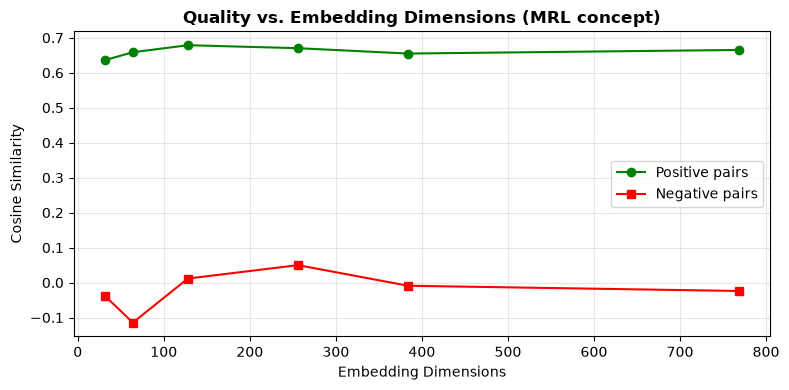

In [7]:
# Matryoshka loss implementation
class MatryoshkaLoss(nn.Module):
    def __init__(self, base_loss, granularities=[64, 128, 256, 512, 768], weights=None):
        super().__init__()
        self.base_loss = base_loss
        self.granularities = granularities
        self.weights = weights or [1.0] * len(granularities)
        
    def forward(self, embeddings_a, embeddings_b, labels=None):
        total_loss = 0
        for dim, w in zip(self.granularities, self.weights):
            # Use only first `dim` dimensions
            sub_a = F.normalize(embeddings_a[:, :dim], dim=-1)
            sub_b = F.normalize(embeddings_b[:, :dim], dim=-1)
            loss = self.base_loss(sub_a, sub_b, labels)
            total_loss += w * loss
        return total_loss


# Demo: how quality degrades with dimension truncation
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# OpenAI text-embedding-3-large supports Matryoshka shortening
# Here we simulate with a standard model
model = SentenceTransformer('all-mpnet-base-v2')  # 768-dim

positive_pairs = [
    ("The quick brown fox", "A fast auburn canid"),
    ("Machine learning algorithms", "Algorithms for training ML models"),
    ("Paris is the capital of France", "France's capital city is Paris"),
]
negative_pairs = [
    ("The quick brown fox", "Machine learning algorithms"),
    ("Paris is the capital", "The quick brown fox"),
]

all_sents = [s for pair in positive_pairs + negative_pairs for s in pair]
embs = model.encode(all_sents)  # (10, 768)

dims = [32, 64, 128, 256, 384, 768]
pos_sims, neg_sims = [], []

for d in dims:
    emb_d = embs[:, :d]
    emb_d = emb_d / (np.linalg.norm(emb_d, axis=1, keepdims=True) + 1e-8)
    
    # Positive pairs are indices 0-5, negative pairs 6-9
    p_sim = np.mean([cosine_similarity([emb_d[2*i]], [emb_d[2*i+1]])[0,0] for i in range(3)])
    n_sim = np.mean([cosine_similarity([emb_d[2*i+6]], [emb_d[2*i+7]])[0,0] for i in range(2)])
    pos_sims.append(p_sim)
    neg_sims.append(n_sim)

plt.figure(figsize=(8, 4))
plt.plot(dims, pos_sims, 'g-o', label='Positive pairs')
plt.plot(dims, neg_sims, 'r-s', label='Negative pairs')
plt.xlabel('Embedding Dimensions')
plt.ylabel('Cosine Similarity')
plt.title('Quality vs. Embedding Dimensions (MRL concept)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Embedding Quantization

Quantizing embeddings from float32/float16 to binary/int8 dramatically reduces storage and speeds up search.

### Binary Quantization

Convert each float to a single bit:

$$b_i = \begin{cases} 1 & \text{if } v_i > 0 \\ 0 & \text{if } v_i \leq 0 \end{cases}$$

Similarity: **Hamming distance** (XOR + popcount) is extremely fast on modern CPUs.

**Storage**: 768-dim float32 (3072 bytes) → 768-bit binary (96 bytes) **32× compression!**

### Scalar (int8) Quantization

$$q_i = \text{round}\left(\frac{v_i - v_{\min}}{v_{\max} - v_{\min}} \times 255\right)$$

**4× compression** (float32 → int8) with minimal quality loss (~97% of float32 quality).

### Cohere's Approach

Cohere Embed v3 natively supports compressed embeddings trained with quantization-aware training so the binary/int8 embeddings are optimized from the start (not just post-hoc quantization).

In [8]:
# Embedding quantization
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

def binary_quantize(embeddings):
    """Binarize embeddings (sign binarization)."""
    return (embeddings > 0).astype(np.uint8)

def scalar_quantize(embeddings, bits=8):
    """Scalar quantization to int8."""
    max_val = np.max(embeddings)
    min_val = np.min(embeddings)
    scale = (2**bits - 1) / (max_val - min_val + 1e-8)
    quantized = np.round((embeddings - min_val) * scale).astype(np.uint8)
    return quantized, min_val, scale

def scalar_dequantize(quantized, min_val, scale):
    return quantized.astype(np.float32) / scale + min_val

def hamming_similarity(a_bin, b_bin):
    """Similarity via Hamming distance (lower = more similar)."""
    xor = np.bitwise_xor(a_bin, b_bin)
    hamming_dist = np.sum(xor)  # count differing bits
    max_dist = a_bin.size
    return 1 - hamming_dist / max_dist

# Load and embed
model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = ["Paris is the capital of France", "France's capital is Paris",
             "The Eiffel Tower is in Paris", "Machine learning is fascinating"]
embeddings = model.encode(sentences)  # float32, (4, 384)

# Quantize
binary = binary_quantize(embeddings)
int8, min_v, scale = scalar_quantize(embeddings)
dequant = scalar_dequantize(int8, min_v, scale)

# Compare similarity quality
cos_float = cosine_similarity([embeddings[0]], [embeddings[1]])[0,0]
cos_dequant = cosine_similarity([dequant[0]], [dequant[1]])[0,0]
ham_sim = hamming_similarity(binary[0], binary[1])

print("Similarity between 'Paris...' sentences:")
print(f"  Float32 cosine:     {cos_float:.4f}")
print(f"  int8 cosine:        {cos_dequant:.4f}  ({100*cos_dequant/cos_float:.1f}% of float)")
print(f"  Binary Hamming sim: {ham_sim:.4f}")

print(f"\nStorage comparison (384-dim):")
print(f"  float32: {384*4} bytes")
print(f"  int8:    {384} bytes  ({4:.0f}× smaller)")
print(f"  binary:  {384//8} bytes ({32:.0f}× smaller)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Similarity between 'Paris...' sentences:
  Float32 cosine:     0.9896
  int8 cosine:        0.9894  (100.0% of float)
  Binary Hamming sim: 0.9557

Storage comparison (384-dim):
  float32: 1536 bytes
  int8:    384 bytes  (4× smaller)
  binary:  48 bytes (32× smaller)


## 8. MTEB Benchmark

**Massive Text Embedding Benchmark** (Muennighoff et al., 2022)

The standard evaluation suite for sentence/text embedding models.

### 8 Task Categories, 56 Datasets

| Task | Description | Metric | Example Datasets |
|------|-------------|--------|------------------|
| **Retrieval** | Query → relevant document | nDCG@10 | MSMARCO, HotpotQA, BEIR |
| **STS** | Sentence pair similarity score | Spearman | STS12-22, STS-B |
| **Clustering** | Group similar texts | V-Measure | ArxivClustering, Reddit |
| **Classification** | Embed → classify | Accuracy | AmazonReviews, Banking77 |
| **Reranking** | Rerank candidate docs | MAP | AskUbuntu, MindSmallReranking |
| **PairClassification** | Is this pair similar? | AP | TwitterSemEval, SprintDup |
| **Summarization** | Embed summaries vs articles | Spearman | SummEval |
| **BitextMining** | Find parallel sentences | F1 | BUCC, Tatoeba |

### MTEB Leaderboard (approximate, as of mid-2024)

| Rank | Model | Avg Score | Retrieval |
|------|-------|-----------|----------|
| 1 | voyage-large-2-instruct | 67.1 | 74.8 |
| 2 | text-embedding-3-large | 64.6 | 72.5 |
| 3 | gte-Qwen2-7B-instruct | 66.1 | 72.2 |
| 4 | stella_en_1.5B_v5 | 65.8 | 72.0 |
| 5 | e5-mistral-7b-instruct | 66.6 | 74.9 |
| 10 | bge-large-en-v1.5 | 64.2 | 70.5 |
| 15 | all-mpnet-base-v2 | 57.8 | 43.8 |

Live leaderboard: https://huggingface.co/spaces/mteb/leaderboard

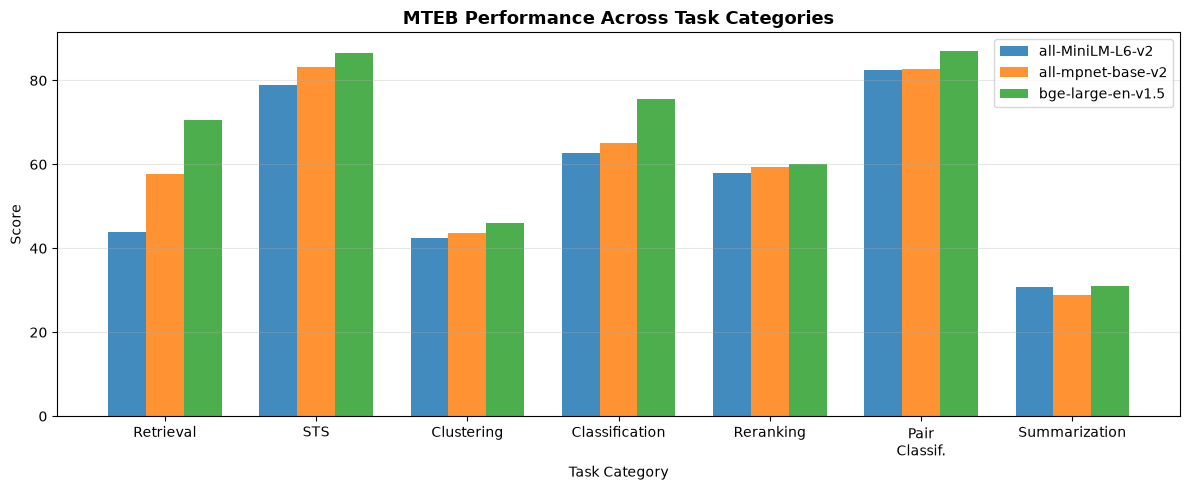

In [9]:
# Evaluate a model on MTEB
# pip install mteb

# Quick MTEB evaluation example (conceptual)
def run_mteb_evaluation():
    import mteb
    from sentence_transformers import SentenceTransformer
    
    # Load model
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # Run specific tasks
    tasks = mteb.get_tasks(tasks=["STSBenchmark", "TRECCOVID", "ArxivClusteringS2S"])
    evaluation = mteb.MTEB(tasks=tasks)
    results = evaluation.run(model, output_folder="./mteb_results")
    return results

# Visualize MTEB dimensions
categories = ['Retrieval', 'STS', 'Clustering', 'Classification', 
               'Reranking', 'Pair\nClassif.', 'Summarization']

models_data = {
    'all-MiniLM-L6-v2': [43.8, 78.9, 42.4, 62.6, 58.0, 82.4, 30.8],
    'all-mpnet-base-v2': [57.8, 83.1, 43.7, 65.1, 59.4, 82.6, 28.8],
    'bge-large-en-v1.5': [70.5, 86.6, 46.1, 75.6, 60.1, 87.1, 31.0],
}

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, scores) in enumerate(models_data.items()):
    bars = ax.bar(x + i*width, scores, width, label=model_name, alpha=0.85)

ax.set_xlabel('Task Category')
ax.set_ylabel('Score')
ax.set_title('MTEB Performance Across Task Categories', fontweight='bold', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Practical Applications

In [10]:
# Application 1: Semantic Search
from sentence_transformers import SentenceTransformer, util
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

# Corpus
corpus = [
    "Python is a high-level programming language known for its readability",
    "Machine learning is a subset of artificial intelligence",
    "The transformer architecture uses self-attention mechanisms",
    "NumPy provides efficient array operations in Python",
    "Deep learning models require large amounts of training data",
    "BERT is a bidirectional language model pre-trained on masked language modeling",
    "PyTorch is a popular deep learning framework with dynamic computation graphs",
    "The Eiffel Tower is located in Paris, France",
    "French cuisine is known for its sophistication and variety",
]

# Encode corpus (offline)
corpus_embeddings = model.encode(corpus, convert_to_tensor=True)

def semantic_search(query, corpus, corpus_embeddings, model, top_k=3):
    query_embedding = model.encode(query, convert_to_tensor=True)
    scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
    top_results = torch.topk(scores, k=top_k)
    
    print(f"Query: '{query}'")
    print("Results:")
    for score, idx in zip(top_results.values, top_results.indices):
        print(f"  [{score:.3f}] {corpus[idx]}")
    print()

semantic_search("how do attention mechanisms work in NLP?", corpus, corpus_embeddings, model)
semantic_search("Python libraries for numerical computation", corpus, corpus_embeddings, model)
semantic_search("deep neural network training", corpus, corpus_embeddings, model)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Query: 'how do attention mechanisms work in NLP?'
Results:
  [0.474] The transformer architecture uses self-attention mechanisms
  [0.394] BERT is a bidirectional language model pre-trained on masked language modeling
  [0.165] Machine learning is a subset of artificial intelligence

Query: 'Python libraries for numerical computation'
Results:
  [0.494] NumPy provides efficient array operations in Python
  [0.477] Python is a high-level programming language known for its readability
  [0.357] PyTorch is a popular deep learning framework with dynamic computation graphs

Query: 'deep neural network training'
Results:
  [0.578] Deep learning models require large amounts of training data
  [0.467] PyTorch is a popular deep learning framework with dynamic computation graphs
  [0.383] Machine learning is a subset of artificial intelligence



In [11]:
# Application 2: Duplicate Detection / Paraphrase Mining
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "What is the capital of France?",
    "Where is the Eiffel Tower?",
    "Which city is France's capital?",    # dup of 0
    "How do neural networks learn?",
    "What is the learning process for deep learning models?",  # dup of 3
    "Paris is where the Eiffel Tower stands",  # dup of 1
    "What is machine learning?",
]

# Efficient paraphrase mining
paraphrases = util.paraphrase_mining(
    model, sentences,
    top_k=10,
    score_function=util.cos_sim
)

print("Detected paraphrases (threshold=0.7):")
for score, i, j in paraphrases:
    if score > 0.7:
        print(f"  [{score:.3f}] \"{sentences[i]}\"")
        print(f"           ≈ \"{sentences[j]}\"")
        print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Detected paraphrases (threshold=0.7):
  [0.935] "What is the capital of France?"
           ≈ "Which city is France's capital?"

  [0.824] "Where is the Eiffel Tower?"
           ≈ "Paris is where the Eiffel Tower stands"



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

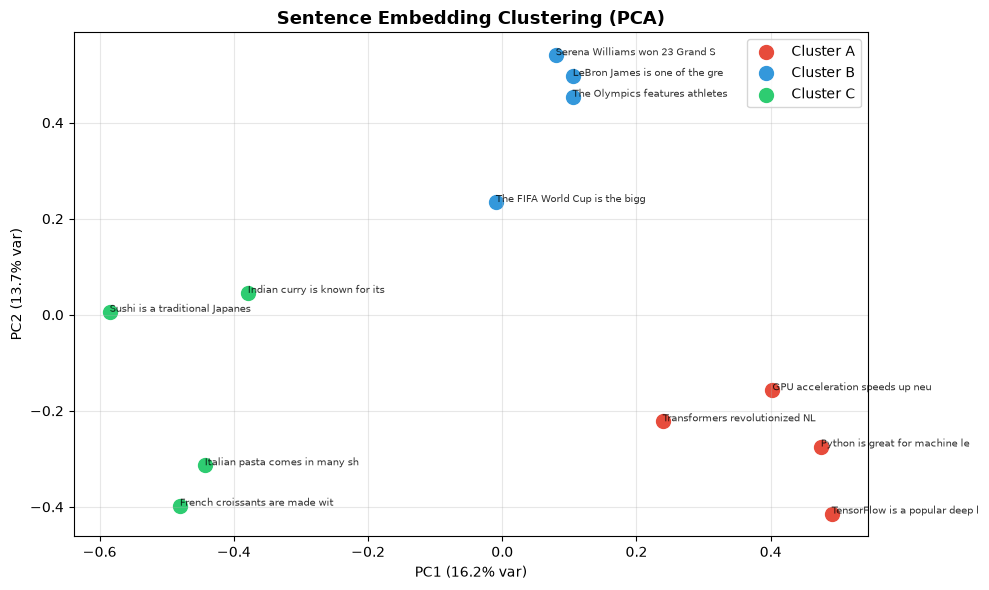


Clusters found:
  Cluster 0: ['Python is great for machine learning', 'TensorFlow is a popular deep learning framework', 'GPU acceleration speeds up neural network training', 'Transformers revolutionized NLP tasks']
  Cluster 1: ['The FIFA World Cup is the biggest football tournament', 'LeBron James is one of the greatest basketball players', 'Serena Williams won 23 Grand Slam titles', 'The Olympics features athletes from around the world']
  Cluster 2: ['Italian pasta comes in many shapes and sizes', 'Sushi is a traditional Japanese dish', 'French croissants are made with buttery laminated dough', 'Indian curry is known for its rich spices']


In [12]:
# Application 3: Clustering with embeddings
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

texts = [
    # Technology cluster
    "Python is great for machine learning",
    "TensorFlow is a popular deep learning framework",
    "GPU acceleration speeds up neural network training",
    "Transformers revolutionized NLP tasks",
    # Sports cluster
    "The FIFA World Cup is the biggest football tournament",
    "LeBron James is one of the greatest basketball players",
    "Serena Williams won 23 Grand Slam titles",
    "The Olympics features athletes from around the world",
    # Food cluster
    "Italian pasta comes in many shapes and sizes",
    "Sushi is a traditional Japanese dish",
    "French croissants are made with buttery laminated dough",
    "Indian curry is known for its rich spices",
]

embeddings = model.encode(texts)

# Cluster
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

# Visualize with PCA
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)

colors = ['#e74c3c', '#3498db', '#2ecc71']
cluster_names = ['Cluster A', 'Cluster B', 'Cluster C']

fig, ax = plt.subplots(figsize=(10, 6))
for cluster_id in range(3):
    mask = labels == cluster_id
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
               c=colors[cluster_id], s=100, label=cluster_names[cluster_id])
    for i, txt in enumerate(np.array(texts)[mask]):
        ax.annotate(txt[:30], (emb_2d[mask][i, 0], emb_2d[mask][i, 1]),
                   fontsize=7, alpha=0.8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('Sentence Embedding Clustering (PCA)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nClusters found:")
for c in range(3):
    print(f"  Cluster {c}: {[texts[i] for i, l in enumerate(labels) if l == c]}")

## Additional Learning Resources

### Foundational Papers

| Paper | Link |
|-------|------|
| SBERT: Sentence Embeddings using Siamese BERT | https://arxiv.org/abs/1908.10084 |
| InferSent: Supervised Learning of Universal Sentence Representations | https://arxiv.org/abs/1705.02364 |
| Universal Sentence Encoder (USE) | https://arxiv.org/abs/1803.11175 |
| LASER: Language-Agnostic Sentence Representations | https://arxiv.org/abs/1812.10464 |
| LaBSE: Language-agnostic BERT Sentence Embedding | https://arxiv.org/abs/2007.01852 |
| E5: Text Embeddings by Weakly-Supervised Contrastive Pre-training | https://arxiv.org/abs/2212.03533 |
| BGE M3-Embedding | https://arxiv.org/abs/2402.03216 |
| Instructor: One Embedder, Any Task | https://arxiv.org/abs/2212.09741 |
| GritLM: Generative Representational Instruction Tuning | https://arxiv.org/abs/2402.09906 |
| Matryoshka Representation Learning | https://arxiv.org/abs/2205.13147 |
| MTEB: Massive Text Embedding Benchmark | https://arxiv.org/abs/2210.07316 |
| SimCSE: Simple Contrastive Learning | https://arxiv.org/abs/2104.08821 |

### Libraries and Tools
- **sentence-transformers**: https://github.com/UKPLab/sentence-transformers
- **FAISS** (fast similarity search): https://github.com/facebookresearch/faiss
- **MTEB leaderboard**: https://huggingface.co/spaces/mteb/leaderboard
- **Qdrant** (vector database): https://qdrant.tech/
- **Weaviate** (vector database): https://weaviate.io/

### Tutorials
- Sentence Transformers documentation: https://www.sbert.net/
- HuggingFace text embedding guide: https://huggingface.co/blog/mteb
- Nils Reimers' SBERT tutorial: https://www.sbert.net/docs/training/overview.html